In [32]:
import pandas as pd
import keras
import tensorflow as tf

In [33]:
# Reading train and test data
train_data = pd.read_csv('dataset/fashion_mnist_train.csv')
test_data = pd.read_csv('dataset/fashion_mnist_test.csv')

# Class Names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']



In [34]:
# Split Validation & Test Data
val_data = test_data.iloc[:5000,:]
test_data = test_data.iloc[5000:,:]

# Extract labels
train_labels = train_data.label
val_labels = val_data.label
test_labels = test_data.label

In [37]:
print('test_data shape:', test_data.shape)          # (rows, cols)
assert test_data.shape[1] - 1 == 28*28, "Expected 784 pixels per row"

test_data shape: (1000, 785)


In [38]:
# Reshaping the flattened data into 28x28 images
train_images = train_data.iloc[:,1:].values.reshape(60000, 28, 28)

# Reshaping hte validation data
val_images = val_data.iloc[:,1:].values.reshape(5000, 28, 28)

# Reshaping the test data
test_images = test_data.iloc[:,1:].values.reshape(1000, 28, 28)

# Scaling the data in range of 0 t 1
train_images = train_images / 255.0
val_images = val_images / 255.0
# test_images = test_images / 255.0

In [39]:
# Defining multi-layer perceptron model with 1 hidden layer having 1 neuron
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Perform conversion of higher dimensional data (here, 2-D) to 1-D data.
    keras.layers.Dense(10, activation=tf.keras.activations.linear), # Hidden layer with 1 neuron and linear activation function
    keras.layers.Dense(10, activation=tf.keras.activations.linear) # Output layer with linear activation function 
])                                                   
# Defining parameters like optimizer, loss function and evaluating metric
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(), 
              metrics=['accuracy'])
model1 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 310us/step - accuracy: 0.4123 - loss: 1.8923 - val_accuracy: 0.4820 - val_loss: 2.2771
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 282us/step - accuracy: 0.4548 - loss: 2.2829 - val_accuracy: 0.4462 - val_loss: 2.2842
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 274us/step - accuracy: 0.4108 - loss: 2.2895 - val_accuracy: 0.3024 - val_loss: 2.2901
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 276us/step - accuracy: 0.2620 - loss: 2.2924 - val_accuracy: 0.2402 - val_loss: 2.2911
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 275us/step - accuracy: 0.2405 - loss: 2.2880 - val_accuracy: 0.2416 - val_loss: 2.2855


In [40]:
# Defining multi-layer perceptron model with 1 hidden layer having 10 neurons 
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Perform conversion of higher dimensional data (here, 2-D) to 1-D data.
    keras.layers.Dense(10, activation=tf.keras.activations.linear), # Hidden layer with 10 neurons and linear activation function
    keras.layers.Dense(10, activation=tf.keras.activations.linear) # Output layer with linear activation function 
])

# Defining parameters like optimizer, loss function and evaluating metric
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(), # Learning rate and momentum can be passed inside optimizer
              metrics=['accuracy'])

model2 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 308us/step - accuracy: 0.3149 - loss: 2.4391 - val_accuracy: 0.2740 - val_loss: 2.3068
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 276us/step - accuracy: 0.2988 - loss: 2.3029 - val_accuracy: 0.2716 - val_loss: 2.3026
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step - accuracy: 0.1743 - loss: 2.3082 - val_accuracy: 0.1106 - val_loss: 2.3026
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 274us/step - accuracy: 0.1089 - loss: 2.3028 - val_accuracy: 0.1108 - val_loss: 2.3026
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 276us/step - accuracy: 0.1090 - loss: 2.3026 - val_accuracy: 0.1108 - val_loss: 2.3026


In [41]:
# Defining multi-layer perceptron model with 1 hidden layer having 10 neurons with non-linearity
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Perform conversion of higher dimensional data (here, 2-D) to 1-D data.
    keras.layers.Dense(10, activation=tf.nn.relu), # Hidden layer with 10 neurons and ReLU activation function
    keras.layers.Dense(10, activation=tf.nn.softmax) # Output layer with softmax activation function 
])

# Defining parameters like optimizer, loss function and evaluating metric
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=keras.optimizers.Adam(), # Learning rate and momentum can be passed inside optimizer
              metrics=['accuracy'])

model3 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 300us/step - accuracy: 0.7694 - loss: 0.6741 - val_accuracy: 0.8262 - val_loss: 0.4945
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step - accuracy: 0.8381 - loss: 0.4601 - val_accuracy: 0.8468 - val_loss: 0.4485
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 269us/step - accuracy: 0.8479 - loss: 0.4309 - val_accuracy: 0.8462 - val_loss: 0.4382
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 273us/step - accuracy: 0.8547 - loss: 0.4143 - val_accuracy: 0.8516 - val_loss: 0.4173
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 291us/step - accuracy: 0.8580 - loss: 0.4043 - val_accuracy: 0.8528 - val_loss: 0.4271


In [42]:
model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10)
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model3 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 522us/step - accuracy: 0.8205 - loss: 0.5044 - val_accuracy: 0.8456 - val_loss: 0.4222
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 487us/step - accuracy: 0.8633 - loss: 0.3781 - val_accuracy: 0.8678 - val_loss: 0.3780
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 489us/step - accuracy: 0.8759 - loss: 0.3413 - val_accuracy: 0.8766 - val_loss: 0.3356
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 486us/step - accuracy: 0.8844 - loss: 0.3170 - val_accuracy: 0.8864 - val_loss: 0.3086
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 485us/step - accuracy: 0.8904 - loss: 0.2996 - val_accuracy: 0.8904 - val_loss: 0.3007


In [43]:
model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model3 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 543us/step - accuracy: 0.8221 - loss: 0.4971 - val_accuracy: 0.8360 - val_loss: 0.4292
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 510us/step - accuracy: 0.8643 - loss: 0.3734 - val_accuracy: 0.8658 - val_loss: 0.3619
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 512us/step - accuracy: 0.8756 - loss: 0.3357 - val_accuracy: 0.8866 - val_loss: 0.3143
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 528us/step - accuracy: 0.8842 - loss: 0.3126 - val_accuracy: 0.8882 - val_loss: 0.3079
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 516us/step - accuracy: 0.8899 - loss: 0.2961 - val_accuracy: 0.8952 - val_loss: 0.2886


In [44]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
model3 = model.fit(train_images, train_labels, epochs=5, validation_data=(val_images, val_labels))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8612 - loss: 0.3926 - val_accuracy: 0.9002 - val_loss: 0.2799
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9038 - loss: 0.2654 - val_accuracy: 0.9204 - val_loss: 0.2287
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9187 - loss: 0.2200 - val_accuracy: 0.9356 - val_loss: 0.1907
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9308 - loss: 0.1887 - val_accuracy: 0.9396 - val_loss: 0.1682
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9406 - loss: 0.1619 - val_accuracy: 0.9502 - val_loss: 0.1351


In [45]:
test_loss, test_accuracy = model.evaluate(test_images, test_labels)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 924us/step - accuracy: 0.9100 - loss: 26.7365
Test Loss: 26.73649787902832
Test Accuracy: 0.9100000262260437


In [46]:
import numpy as np

predictions = model.predict(train_images)

print(predictions.shape)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 559us/step
(60000, 10)


In [47]:
print(predictions[0])

[3.7883439e-03 5.7880393e-06 9.3222536e-02 4.7868122e-03 8.7124884e-01
 2.4909184e-07 2.1522842e-02 4.3390619e-04 3.5753627e-03 1.4154251e-03]


In [58]:
test_labels = np.array(test_labels)

predictions = model.predict(test_images)

predicted_classes = np.argmax(predictions, axis=1)

wrong_indices = np.where(predicted_classes != test_labels)[0]

print("Total mistakes:", len(wrong_indices))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Total mistakes: 90


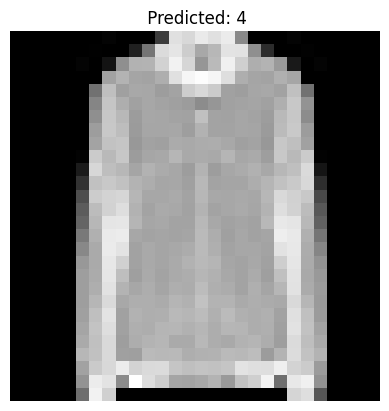

In [54]:
import matplotlib.pyplot as plt

index = 0

plt.imshow(test_images[index], cmap='gray')
plt.title(f" Predicted: {np.argmax(predictions[index])}")
plt.axis('off')
plt.show()

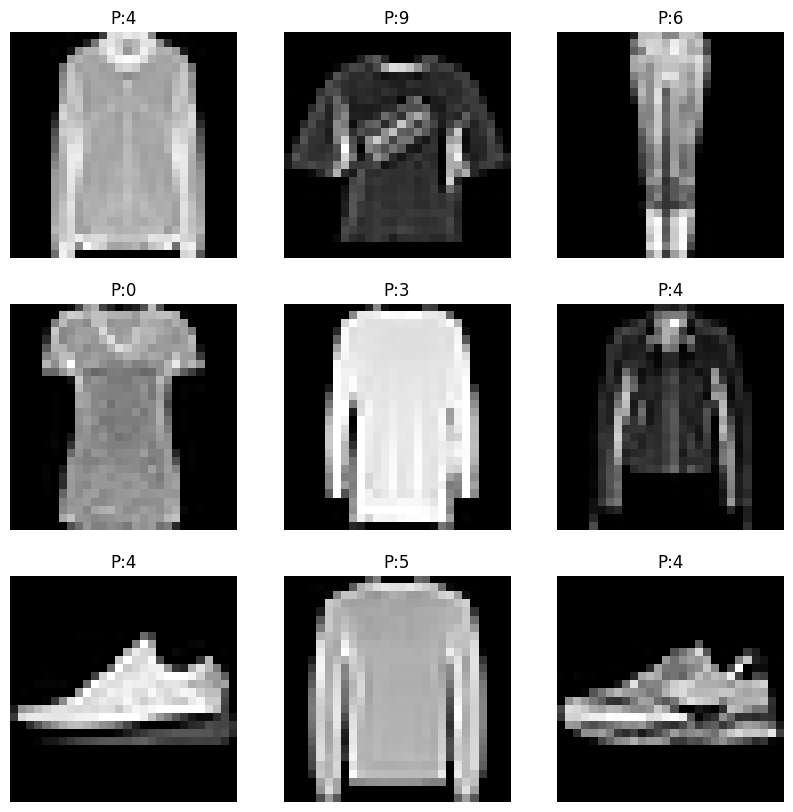

In [56]:
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(test_images[i], cmap='gray')
    plt.title(f"P:{np.argmax(predictions[i])}")
    plt.axis('off')

plt.show()

In [59]:
predicted_classes = np.argmax(predictions, axis=1)

wrong_indices = np.where(predicted_classes != test_labels)[0]

print("Total mistakes:", len(wrong_indices))

Total mistakes: 90


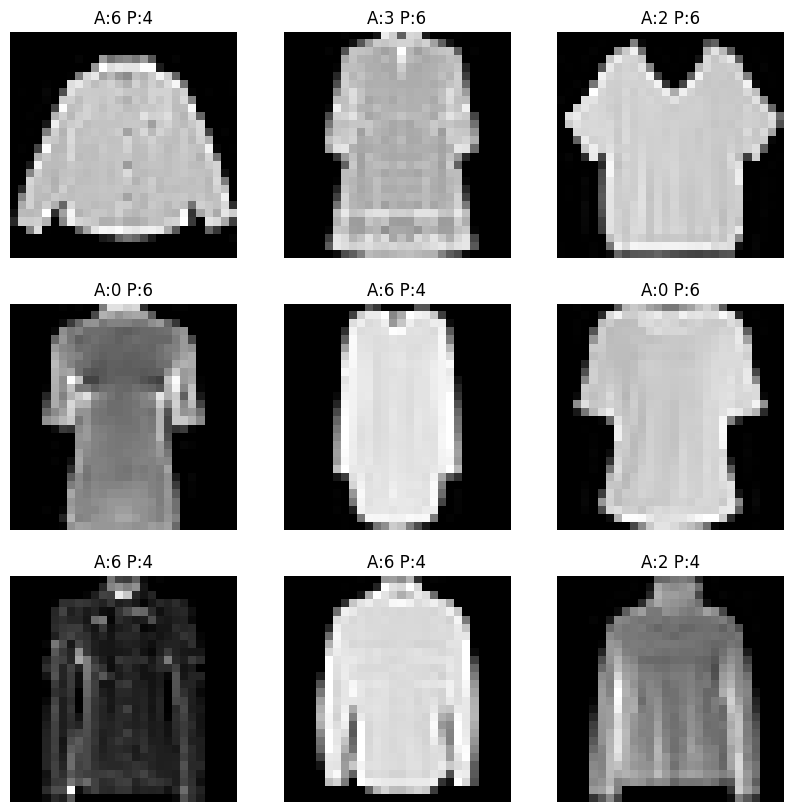

In [60]:
plt.figure(figsize=(10,10))

for i in range(9):
    idx = wrong_indices[i]

    plt.subplot(3,3,i+1)
    plt.imshow(test_images[idx], cmap='gray')
    plt.title(f"A:{test_labels[idx]} P:{predicted_classes[idx]}")
    plt.axis('off')

plt.show()

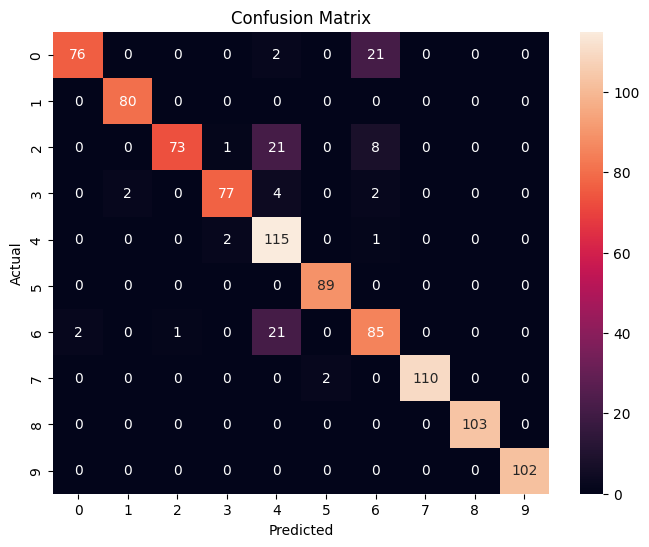

In [62]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [63]:
model.save("mnist_mlp_model.keras")

In [64]:
from tensorflow import keras

loaded_model = keras.models.load_model("mnist_mlp_model.keras")

In [65]:
loaded_model.evaluate(test_images, test_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 879us/step - accuracy: 0.9100 - loss: 26.7365


/Volumes/Vivek's SSD/Building An ANN Model/DLenv/lib/python3.13/site-packages/keras/src/backend/tensorflow/nn.py:1216: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


[26.73649787902832, 0.9100000262260437]

In [66]:
from tensorflow import keras
import tensorflow as tf

better_model = keras.Sequential([
    keras.Input(shape=(28,28)),
    keras.layers.Flatten(),

    keras.layers.Dense(256, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

better_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = better_model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 809us/step - accuracy: 0.7860 - loss: 0.5918 - val_accuracy: 0.8438 - val_loss: 0.4274
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.8397 - loss: 0.4487 - val_accuracy: 0.8590 - val_loss: 0.3767
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step - accuracy: 0.8516 - loss: 0.4107 - val_accuracy: 0.8654 - val_loss: 0.3776
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 741us/step - accuracy: 0.8578 - loss: 0.3906 - val_accuracy: 0.8800 - val_loss: 0.3323
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.8661 - loss: 0.3733 - val_accuracy: 0.8726 - val_loss: 0.3332
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.8683 - loss: 0.3615 - val_accuracy: 0.8864 - val_loss: 0.3101
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.8739 - loss: 0.3477 - val_accuracy: 0.8918 - val_loss: 0.3006
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 749us/step - accuracy: 0.8766 -

In [67]:
better_model.evaluate(test_images, test_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 541us/step - accuracy: 0.8840 - loss: 20.8837


[20.883684158325195, 0.8840000033378601]

In [69]:
cnn_model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    train_images,
    train_labels,
    epochs=10,
    validation_data=(val_images, val_labels)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8397 - loss: 0.4403 - val_accuracy: 0.8808 - val_loss: 0.3298
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8915 - loss: 0.2948 - val_accuracy: 0.9054 - val_loss: 0.2663
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9099 - loss: 0.2482 - val_accuracy: 0.9188 - val_loss: 0.2231
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9211 - loss: 0.2167 - val_accuracy: 0.9224 - val_loss: 0.2166
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9293 - loss: 0.1913 - val_accuracy: 0.9396 - val_loss: 0.1689
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9379 - loss: 0.1686 - val_accuracy: 0.9416 - val_loss: 0.1494
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9445 - loss: 0.1481 - val_accuracy: 0.9512 - val_loss: 0.1311
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9513 - loss: 0.1308 - 

In [70]:
cnn_model.evaluate(test_images, test_labels)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8270 - loss: 76.8873 


[76.8873062133789, 0.8270000219345093]

In [71]:
cnn_model.save("mnist_cnn_model.keras")